In [183]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [184]:
stats

<module 'scipy.stats' from 'c:\\Users\\Garv\\Desktop\\ml nbs\\.venv\\Lib\\site-packages\\scipy\\stats\\__init__.py'>

In [185]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [186]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [187]:
# df.info()
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [188]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Age       891 non-null    float64
 2   Fare      891 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 21.0 KB


<Axes: xlabel='Age', ylabel='Density'>

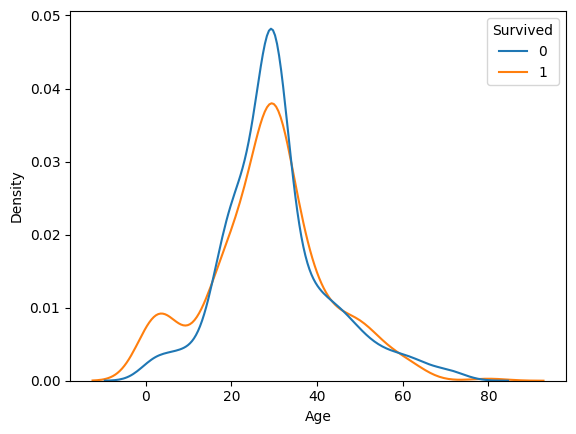

In [189]:
sns.kdeplot(
    data=df,
    x='Age',
    hue='Survived',
    common_norm=False,
    # bw_adjust=0.7,
    # label='Survived Not'
)

In [190]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Survived',axis=1),
                                                 df['Survived'],
                                                 test_size=0.2,
                                                 random_state=42)

In [191]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


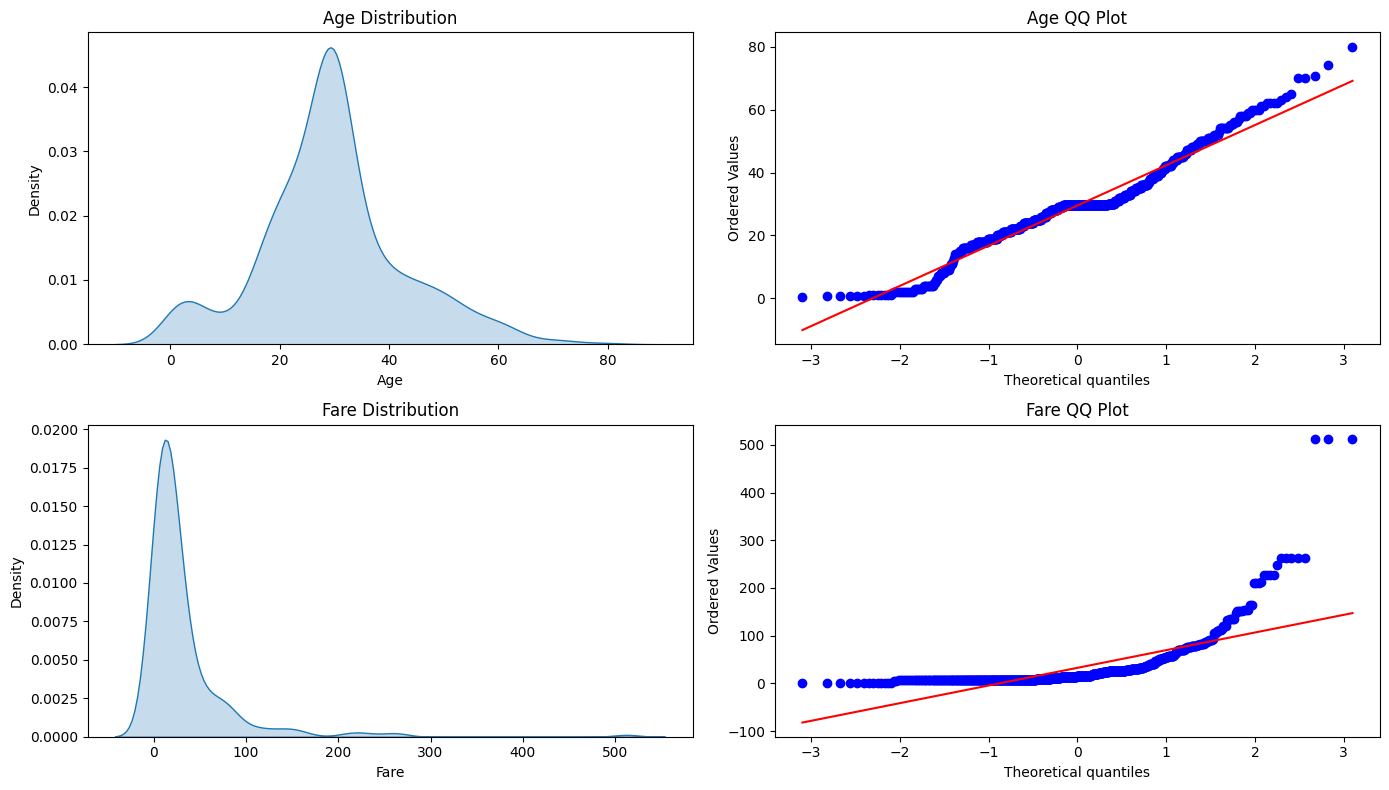

In [192]:
plt.figure(figsize=(14,8))

# Age PDF
plt.subplot(2,2,1)
sns.kdeplot(data=X_train['Age'], fill=True)
plt.title('Age Distribution')
plt.xlabel('Age')

# Fare PDF
plt.subplot(2,2,3)
sns.kdeplot(data=X_train['Fare'], fill=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')

# Age QQ Plot
plt.subplot(2,2,2)
stats.probplot(X_train['Age'].dropna(), dist='norm', plot=plt)
plt.title('Age QQ Plot')

# Fare QQ Plot
plt.subplot(2,2,4)
stats.probplot(X_train['Fare'].dropna(), dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.tight_layout()
plt.show()

In [193]:
clf1 = DecisionTreeClassifier()
clf2 = LogisticRegression()

In [194]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred_dt = clf1.predict(X_test)
y_pred_lr = clf2.predict(X_test)

print("Accuracy for DT", accuracy_score(y_pred_dt,y_test))
print("Accuracy for LR", accuracy_score(y_pred_lr,y_test))

Accuracy for DT 0.664804469273743
Accuracy for LR 0.6480446927374302


## Function Transform

In [195]:
trf = FunctionTransformer(func=np.log1p)

In [196]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

Text(0.5, 1.0, 'After Age')

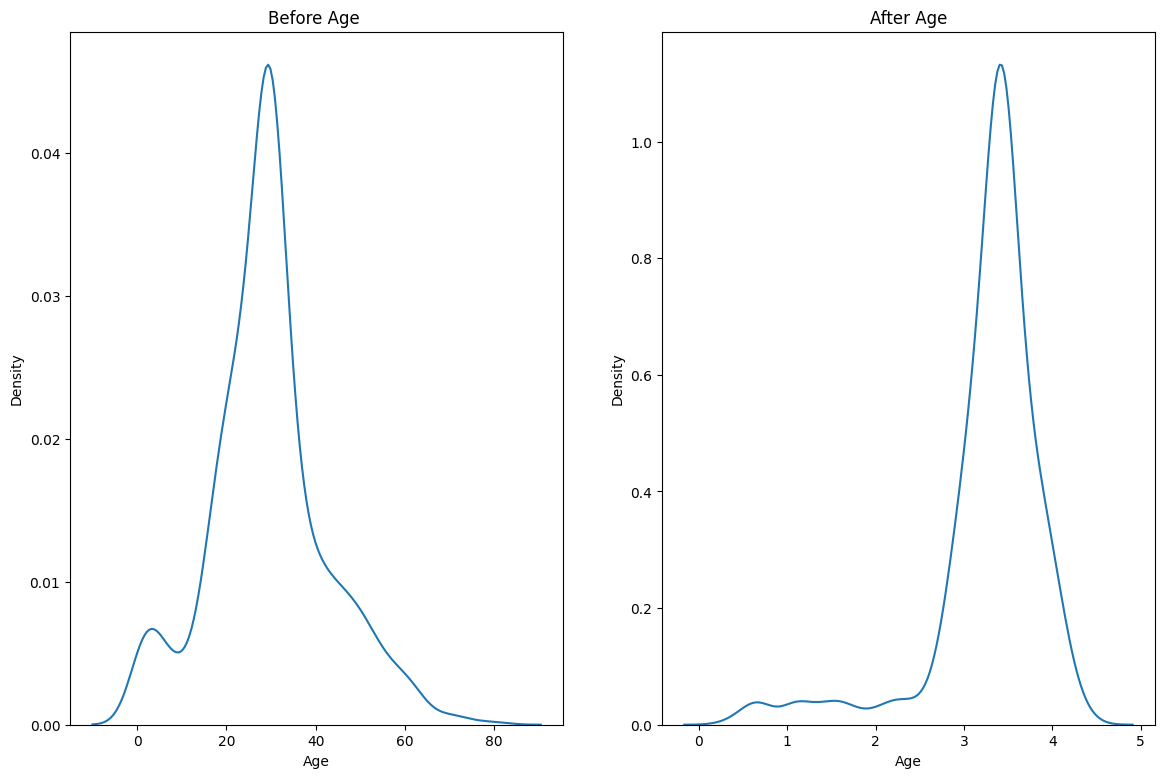

In [197]:
plt.figure(figsize=(14,9))

# Age PDF
plt.subplot(1,2,1)
sns.kdeplot(X_train['Age'])
plt.title('Before Age ')
# plt.xlabel('Age')

# Fare PDF
plt.subplot(1,2,2)
sns.kdeplot(X_train_trf['Age'])
plt.title('After Age')
# plt.xlabel('Fare')

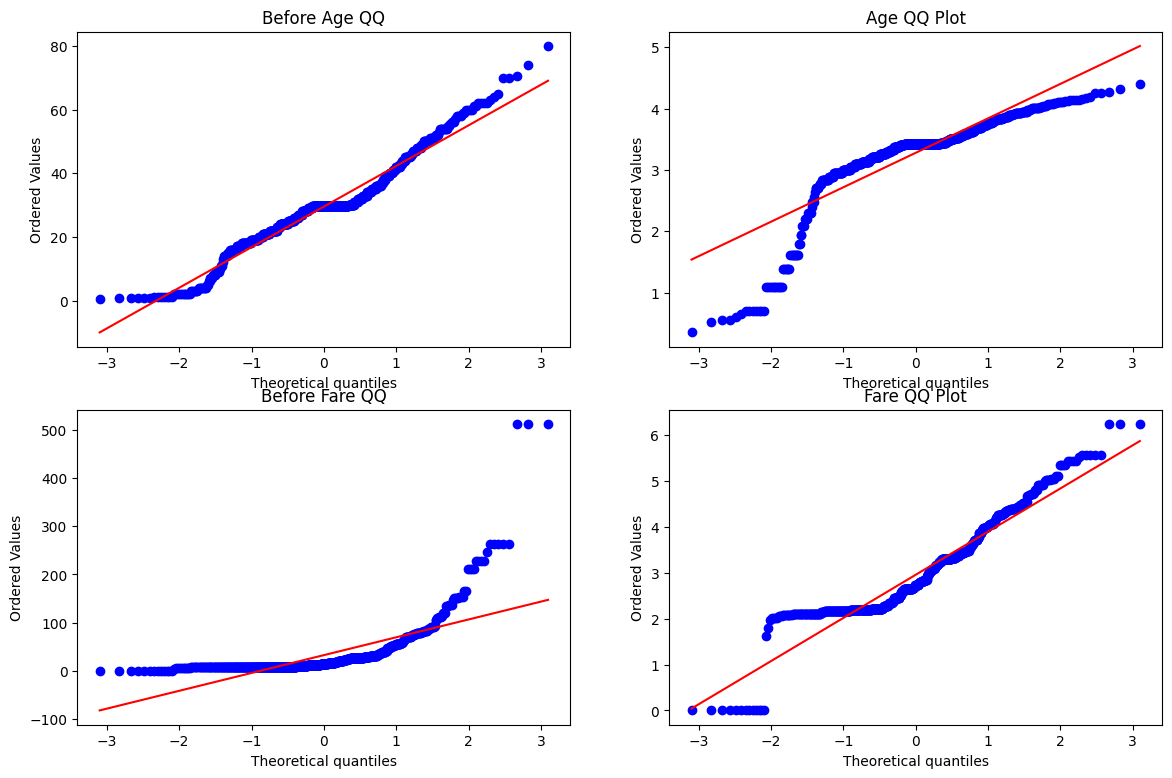

In [198]:
plt.figure(figsize=(14,9))

# Age PDF
plt.subplot(2,2,1)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Before Age QQ')
# plt.xlabel('Age')

# Fare PDF
plt.subplot(2,2,3)
stats.probplot(X_train['Fare'], dist='norm', plot=plt)
plt.title('Before Fare QQ')
# plt.xlabel('Fare')

# Age QQ Plot
plt.subplot(2,2,2)
stats.probplot(X_train_trf['Age'].dropna(), dist='norm', plot=plt)
plt.title('Age QQ Plot')

# Fare QQ Plot
plt.subplot(2,2,4)
stats.probplot(X_train_trf['Fare'].dropna(), dist='norm', plot=plt)
plt.title('Fare QQ Plot')

# plt.tight_layout()
plt.show()

In [199]:
clf1.fit(X_train_trf,y_train)
clf2.fit(X_train_trf,y_train)

y_pred_dt = clf1.predict(X_test_trf)
y_pred_lr = clf2.predict(X_test_trf)

print("Accuracy for DT", accuracy_score(y_pred_dt,y_test))
print("Accuracy for LR", accuracy_score(y_pred_lr,y_test))

Accuracy for DT 0.664804469273743
Accuracy for LR 0.6815642458100558


## CrossVal more accurate

In [200]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('transform', trf),
    ('model', LogisticRegression())
])
pipe2 = Pipeline([
    ('transform', trf),
    ('model', DecisionTreeClassifier())
])

print(np.mean(cross_val_score(pipe, df.drop('Survived',axis=1), df['Survived'], cv=100)))
print(np.mean(cross_val_score(pipe2, df.drop('Survived',axis=1), df['Survived'], cv=100)))

0.68
0.6490277777777778


### Experimenting


In [201]:
X_train['Fare'] = trf.fit_transform(X_train[['Fare']])
X_test['Fare'] = trf.transform(X_test[['Fare']])

In [202]:
X_train.head()

,Age,Fare
331,45.5,3.384390
733,23.0,2.639057
382,32.0,2.188856
704,26.0,2.180892
813,6.0,3.474293


In [203]:
clf1.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred_dt = clf1.predict(X_test)
y_pred_lr = clf2.predict(X_test)

print("Accuracy for DT", accuracy_score(y_pred_dt,y_test))
print("Accuracy for LR", accuracy_score(y_pred_lr,y_test))

Accuracy for DT 0.6927374301675978
Accuracy for LR 0.6703910614525139


## Others

In [204]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.6431335830212235


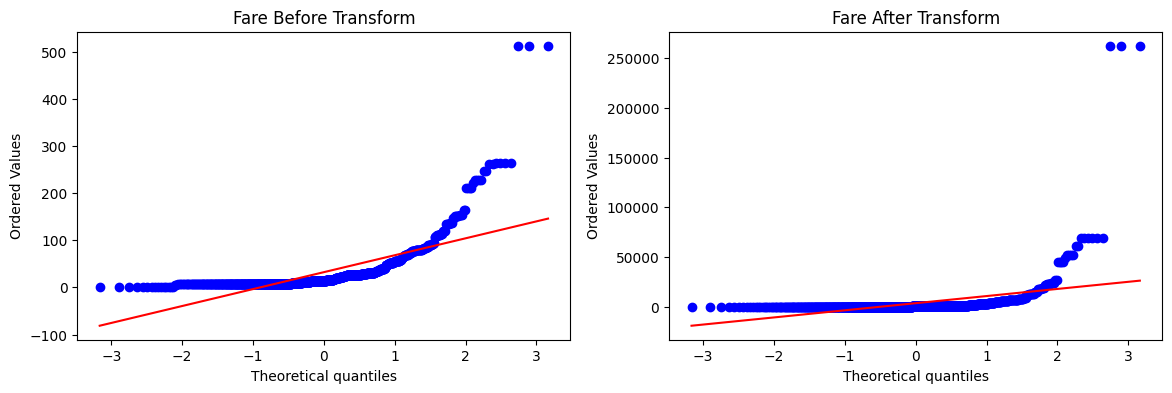

In [205]:
apply_transform(lambda x : x**2)